In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- CONFIG: adjust if your column names differ ----
ID_COL = "cik"
DATE_COL = "end"   # e.g. "period_end", "date", "end_date"
# Optional: industry column if you have one (else keep None)
IND_COL = "sic" if "sic" in locals() else None

# Data path used across notebooks/pipeline (adjust if needed)
DATA_PATH = "../data/interim/balance_sheet_model_with_ratios.parquet"


In [6]:
df = pd.read_parquet(DATA_PATH).copy()

# Basic guards
assert ID_COL in df.columns, f"Missing {ID_COL}"
assert DATE_COL in df.columns, f"Missing {DATE_COL}"

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

print("Rows:", len(df), "| Cols:", df.shape[1])
df.head(3)


Rows: 72575 | Cols: 113


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,...,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,545200000.0,1.131300e+09,NaN,2.859100e+09,...,0.536812,NaN,NaN,NaN,0.053653,0.184813,0.078206,0.346123,0.0,NaN
1,0000001750,2025-05-31,2.844600e+09,1.510600e+09,NaN,1.633000e+09,554700000.0,1.078300e+09,1.211600e+09,2.844600e+09,...,0.531041,0.574070,0.425930,0.339682,0.055720,0.186599,0.077199,0.336040,0.0,0.0
2,0000001750,2025-08-31,2.929700e+09,1.566900e+09,NaN,1.680400e+09,538500000.0,1.141900e+09,1.249300e+09,2.929700e+09,...,0.534833,0.573574,0.426426,0.320459,0.055262,0.185377,0.077107,0.351026,0.0,0.0


In [33]:
TARGET_MAP = {
    # Solvency
    "Assets": "Assets",
    "Liabilities": "Liabilities",
    "Equity": "StockholdersEquity",
    

    # Liquidity
    "CurrentAssets": "AssetsCurrent",
    "CurrentLiabilities": "LiabilitiesCurrent",

    # Cash (recommended primary)
    "Cash": "CashAndCashEquivalentsAtCarryingValue",
    # Alternative broader definition:
    # "Cash": "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents",
}

CANONICAL_TARGETS = list(TARGET_MAP.keys())

missing = [k for k, v in TARGET_MAP.items() if v not in df.columns]
print("Canonical targets:", CANONICAL_TARGETS)
print("Missing mapped cols:", missing)


Canonical targets: ['Assets', 'Liabilities', 'Equity', 'CurrentAssets', 'CurrentLiabilities', 'Cash']
Missing mapped cols: []


In [34]:
avail_overall = pd.DataFrame({
    "target": CANONICAL_TARGETS,
    "source_col": [TARGET_MAP[t] for t in CANONICAL_TARGETS],
    "non_null_rate": [df[TARGET_MAP[t]].notna().mean() for t in CANONICAL_TARGETS],
    "non_null_count": [df[TARGET_MAP[t]].notna().sum() for t in CANONICAL_TARGETS],
}).sort_values("non_null_rate", ascending=False)

avail_overall


,target,source_col,non_null_rate,non_null_count
0,Assets,Assets,1.000000,72575
1,Liabilities,Liabilities,0.945009,68584
2,Equity,StockholdersEquity,0.945009,68584
4,CurrentLiabilities,LiabilitiesCurrent,0.709046,51459
5,Cash,CashAndCashEquivalentsAtCarryingValue,0.705546,51205
3,CurrentAssets,AssetsCurrent,0.703204,51035


In [35]:
df["year"] = df[DATE_COL].dt.year
df["q"] = df[DATE_COL].dt.quarter
df["year_q"] = df["year"].astype(str) + "Q" + df["q"].astype(str)

df["year_q"].value_counts().sort_index().head(20)


year_q
2001Q4       1
2004Q4       1
2005Q4       1
2006Q4       1
2007Q4       2
2008Q3      11
2008Q4      19
2009Q1      17
2009Q2      39
2009Q3      91
2009Q4      68
2010Q1     103
2010Q2     166
2010Q3     264
2010Q4     192
2011Q1     272
2011Q2     996
2011Q3    1568
2011Q4    1248
2012Q1    1677
Name: count, dtype: int64

In [29]:
avail_by_yq = pd.DataFrame({"year_q": sorted(df["year_q"].unique())}).set_index("year_q")

for t in CANONICAL_TARGETS:
    col = TARGET_MAP[t]
    s = df.groupby("year_q")[col].apply(lambda x: x.notna().mean()).sort_index()
    avail_by_yq[t] = s

avail_by_yq.reset_index().head(20)


,year_q,Assets,Liabilities,Equity,TotalDebt,CurrentAssets,CurrentLiabilities,Cash
0,2001Q4,1.0,0.000000,0.000000,1.0,1.000000,1.000000,1.000000
1,2004Q4,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
2,2005Q4,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
3,2006Q4,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
4,2007Q4,1.0,1.000000,1.000000,1.0,1.000000,0.500000,0.500000
5,2008Q3,1.0,0.818182,0.818182,1.0,0.636364,0.636364,0.727273
6,2008Q4,1.0,0.842105,0.842105,1.0,0.789474,0.842105,0.789474
7,2009Q1,1.0,1.000000,1.000000,1.0,0.705882,0.705882,0.823529
8,2009Q2,1.0,0.923077,0.923077,1.0,0.769231,0.769231,0.794872
9,2009Q3,1.0,0.923077,0.923077,1.0,0.648352,0.648352,0.824176


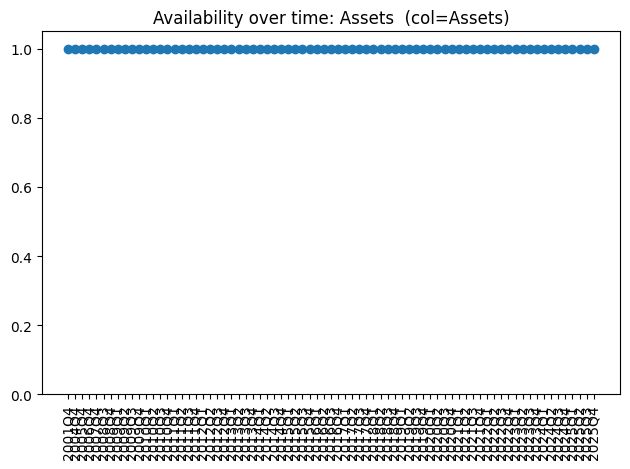

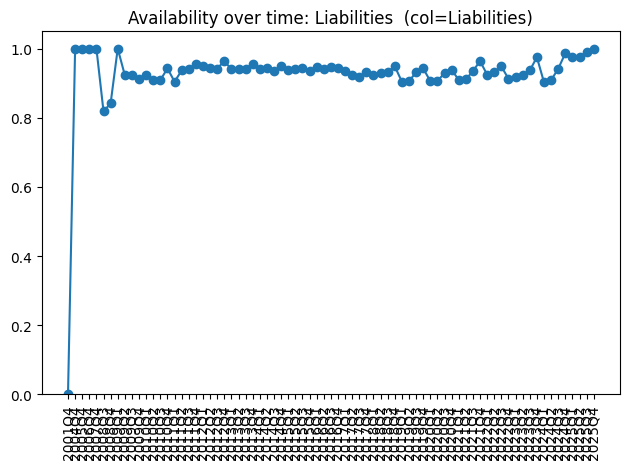

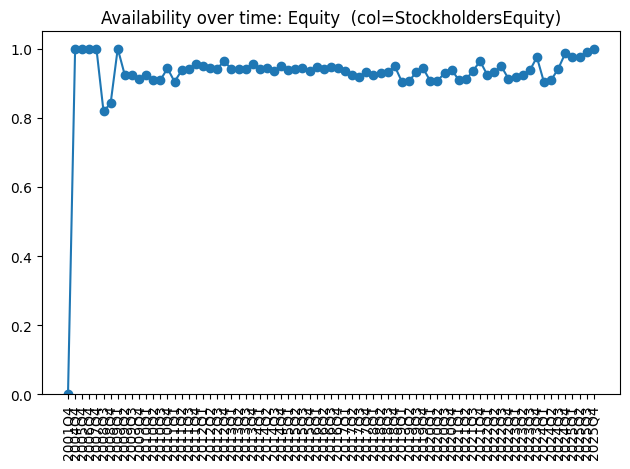

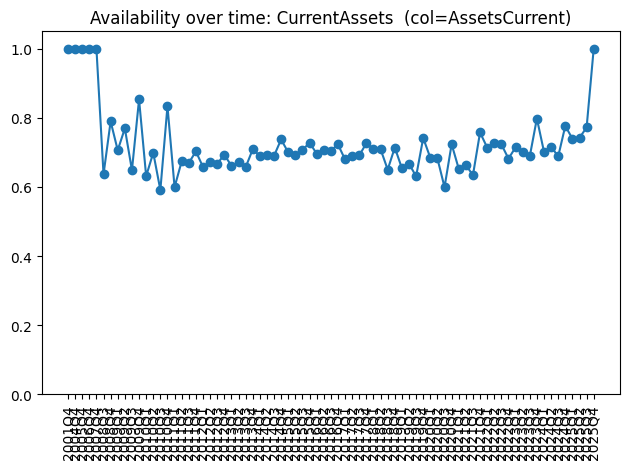

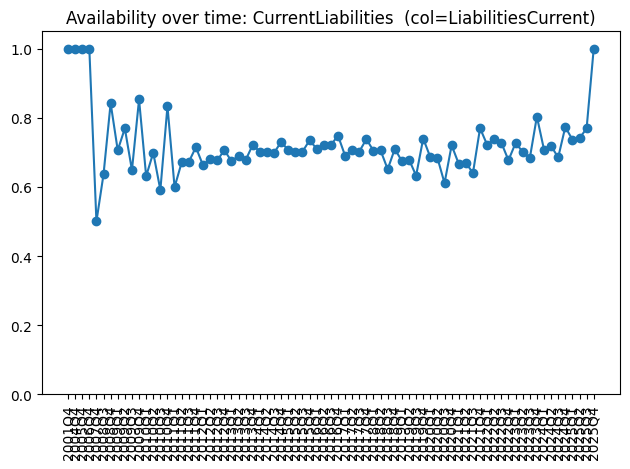

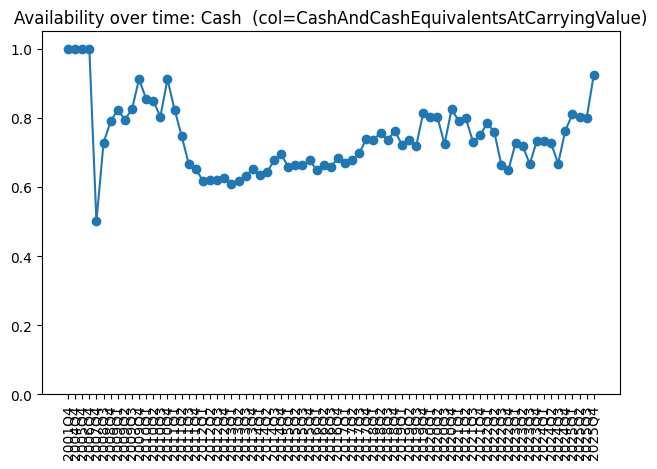

In [17]:
for t in CANONICAL_TARGETS:
    plt.figure()
    plt.plot(avail_by_yq.index, avail_by_yq[t].values, marker="o")
    plt.xticks(rotation=90)
    plt.ylim(0, 1.05)
    plt.title(f"Availability over time: {t}  (col={TARGET_MAP[t]})")
    plt.tight_layout()
    plt.show()


In [18]:
def robust_summary(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return None
    q = s.quantile([0.01, 0.05, 0.50, 0.95, 0.99]).to_dict()
    return {"count": len(s), "p01": q[0.01], "p05": q[0.05], "p50": q[0.50], "p95": q[0.95], "p99": q[0.99]}

dist_rows = []
for t in CANONICAL_TARGETS:
    col = TARGET_MAP[t]
    r = robust_summary(df[col])
    r["target"] = t
    r["source_col"] = col
    dist_rows.append(r)

dist_tbl = pd.DataFrame(dist_rows).set_index("target").sort_values("count", ascending=False)
dist_tbl


,count,p01,p05,p50,p95,p99,source_col
target,,,,,,,
Assets,72575,0.000000e+00,1032.4,151145000.0,2.104687e+10,1.214943e+11,Assets
Liabilities,68584,7.650000e+02,40339.0,39532321.0,1.395140e+10,9.618009e+10,Liabilities
Equity,68584,-5.041700e+08,-21348565.4,25051000.0,5.275691e+09,2.259902e+10,StockholdersEquity
CurrentLiabilities,51459,3.218920e+03,45786.6,15645000.0,2.746285e+09,1.334166e+10,LiabilitiesCurrent
Cash,51205,0.000000e+00,626.4,17647000.0,1.133831e+09,5.551680e+09,CashAndCashEquivalentsAtCarryingValue
CurrentAssets,51035,0.000000e+00,2027.7,24274000.0,3.879600e+09,1.633300e+10,AssetsCurrent


In [19]:
EPS = 1e-6
jump_rows = []

for t in CANONICAL_TARGETS:
    col = TARGET_MAP[t]
    y = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    prev = y.groupby(df[ID_COL]).shift(1)
    diff = y - prev
    pct = diff / (prev.abs() + EPS)

    valid = pct.dropna()
    jump_rows.append({
        "target": t,
        "source_col": col,
        "pct_count": len(valid),
        "abs_pct_median": valid.abs().median() if len(valid) else np.nan,
        "abs_pct_p95": valid.abs().quantile(0.95) if len(valid) else np.nan,
        "jump_gt_100pct": (valid.abs() > 1.0).mean() if len(valid) else np.nan,
        "jump_gt_200pct": (valid.abs() > 2.0).mean() if len(valid) else np.nan,
        "jump_gt_500pct": (valid.abs() > 5.0).mean() if len(valid) else np.nan,
    })

jump_tbl = pd.DataFrame(jump_rows).sort_values("jump_gt_200pct", ascending=False)
jump_tbl


,target,source_col,pct_count,abs_pct_median,abs_pct_p95,jump_gt_100pct,jump_gt_200pct,jump_gt_500pct
5,Cash,CashAndCashEquivalentsAtCarryingValue,37804,0.306872,5.518497,0.138610,0.090969,0.052957
2,Equity,StockholdersEquity,54201,0.081499,2.987062,0.111197,0.066604,0.035682
3,CurrentAssets,AssetsCurrent,38861,0.139357,3.112006,0.088160,0.063303,0.040143
0,Assets,Assets,58268,0.054575,2.004420,0.066881,0.050062,0.035869
4,CurrentLiabilities,LiabilitiesCurrent,39479,0.127000,1.826042,0.076218,0.047164,0.026926
1,Liabilities,Liabilities,54201,0.072980,1.553693,0.066143,0.043080,0.025756


In [20]:
decision = avail_overall.merge(jump_tbl, on=["target","source_col"], how="left")

decision["score"] = (
    0.65 * decision["non_null_rate"].fillna(0)
    - 0.20 * decision["jump_gt_200pct"].fillna(0)
    - 0.15 * decision["jump_gt_500pct"].fillna(0)
)

decision = decision.sort_values("score", ascending=False)
decision[["target","source_col","non_null_rate","jump_gt_200pct","jump_gt_500pct","score"]]


,target,source_col,non_null_rate,jump_gt_200pct,jump_gt_500pct,score
0,Assets,Assets,1.000000,0.050062,0.035869,0.634607
1,Liabilities,Liabilities,0.945009,0.043080,0.025756,0.601776
2,Equity,StockholdersEquity,0.945009,0.066604,0.035682,0.595583
3,CurrentLiabilities,LiabilitiesCurrent,0.709046,0.047164,0.026926,0.447408
5,CurrentAssets,AssetsCurrent,0.703204,0.063303,0.040143,0.438400
4,Cash,CashAndCashEquivalentsAtCarryingValue,0.705546,0.090969,0.052957,0.432467


In [21]:
FINAL_TARGETS = ["Assets", "Liabilities", "Equity", "CurrentAssets", "CurrentLiabilities", "Cash"]

# Not in dataset yet (income statement)
LATER_TARGETS = ["NetIncome", "OperatingIncome"]

print("FINAL_TARGETS:", FINAL_TARGETS)
print("LATER_TARGETS:", LATER_TARGETS)


FINAL_TARGETS: ['Assets', 'Liabilities', 'Equity', 'CurrentAssets', 'CurrentLiabilities', 'Cash']
LATER_TARGETS: ['NetIncome', 'OperatingIncome']


In [22]:
HORIZON = 1  # predict next quarter

for t in FINAL_TARGETS:
    src = TARGET_MAP[t]
    df[f"y_{t}"] = df.groupby(ID_COL)[src].shift(-HORIZON)

y_cols = [f"y_{t}" for t in FINAL_TARGETS]
df_supervised = df.dropna(subset=y_cols, how="any").copy()

print("Supervised rows (complete across all FINAL_TARGETS):", len(df_supervised))
df_supervised[[ID_COL, DATE_COL] + y_cols].head()


Supervised rows (complete across all FINAL_TARGETS): 28435


,cik,end,y_Assets,y_Liabilities,y_Equity,y_CurrentAssets,y_CurrentLiabilities,y_Cash
0,0000001750,2025-02-28,2.844600e+09,1.633000e+09,1.211600e+09,1.510600e+09,5.547000e+08,9.650000e+07
1,0000001750,2025-05-31,2.929700e+09,1.680400e+09,1.249300e+09,1.566900e+09,5.385000e+08,8.000000e+07
3,0000001800,2025-03-31,8.399900e+10,3.343400e+10,5.056500e+10,2.446800e+10,1.343900e+10,6.951000e+09
4,0000001800,2025-06-30,8.418100e+10,3.322700e+10,5.095400e+10,2.483900e+10,1.458200e+10,7.511000e+09
6,0000001961,2017-03-31,9.111400e+04,4.960452e+06,-4.869338e+06,9.111400e+04,4.960452e+06,8.651200e+04


In [23]:
[c for c in df.columns if "debt" in c.lower() and "lag" not in c.lower() and not c.startswith("y_")]


['DebtCurrent',
 'LongTermDebt',
 'LongTermDebtCurrent',
 'debt_to_assets',
 'debt_to_equity']